# Exploratory Data Analysis — NIH ChestX-Ray14 Dataset

**Project:** Multi-Label Thoracic Disease Classification using Deep Learning  
**Dataset:** NIH ChestX-Ray14 — 112,120 frontal chest X-ray images from 30,805 unique patients  

---

## Notebook Objectives
This notebook performs a thorough exploratory analysis of the dataset metadata before any preprocessing or model training. The goal is to understand:
- Dataset structure and size
- Class distribution and imbalance
- Patient demographics (age, gender)
- Follow-up visit patterns
- Image acquisition views (PA vs AP)
- Visual inspection of sample X-ray images

> **Note:** No data is modified or saved in this notebook. All operations are read-only for analysis purposes.

## 1. Imports & Configuration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from warnings import filterwarnings

# Suppress non-critical warnings for cleaner output
filterwarnings("ignore")

# Render matplotlib plots inline inside the notebook
%matplotlib inline

## 2. Load Dataset Metadata

The metadata CSV (`Data_Entry_2017.csv`) contains one row per image with the following key columns:
- `Image Index` — unique filename of the X-ray image
- `Finding Labels` — pipe-separated disease labels (e.g. `Pneumonia|Effusion`)
- `Follow-up #` — visit number for the patient (0 = first visit)
- `Patient ID` — anonymized patient identifier
- `Patient Age` — age in years at time of scan
- `Patient Gender` — M or F
- `View Position` — PA (Posteroanterior) or AP (Anteroposterior)

In [2]:
# Load the metadata CSV file
# Update this path to match your local dataset location
df = pd.read_csv(r"D:\Data\Data_Entry_2017.csv")

# Preview the first 10 rows to confirm successful loading
df.head(10)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN
5,00000003_001.png,Hernia,1,3,74,F,PA,2500,2048,0.168,0.168,NaN
6,00000003_002.png,Hernia,2,3,75,F,PA,2048,2500,0.168,0.168,NaN
7,00000003_003.png,Hernia|Infiltration,3,3,76,F,PA,2698,2991,0.143,0.143,NaN
8,00000003_004.png,Hernia,4,3,77,F,PA,2500,2048,0.168,0.168,NaN
9,00000003_005.png,Hernia,5,3,78,F,PA,2686,2991,0.143,0.143,NaN


In [3]:
# Preview the last 10 rows to check data consistency at the end of the file
df.tail(10)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
112110,00030797_000.png,No Finding,0,30797,24,M,PA,2021,2021,0.194311,0.194311,NaN
112111,00030798_000.png,No Finding,0,30798,30,M,PA,2500,2048,0.171000,0.171000,NaN
112112,00030799_000.png,No Finding,0,30799,32,M,PA,2048,2500,0.171000,0.171000,NaN
112113,00030800_000.png,No Finding,0,30800,34,F,PA,2048,2500,0.168000,0.168000,NaN
112114,00030801_000.png,No Finding,0,30801,39,M,PA,2500,2048,0.168000,0.168000,NaN
112115,00030801_001.png,Mass|Pneumonia,1,30801,39,M,PA,2048,2500,0.168000,0.168000,NaN
112116,00030802_000.png,No Finding,0,30802,29,M,PA,2048,2500,0.168000,0.168000,NaN
112117,00030803_000.png,No Finding,0,30803,42,F,PA,2048,2500,0.168000,0.168000,NaN
112118,00030804_000.png,No Finding,0,30804,30,F,PA,2048,2500,0.168000,0.168000,NaN
112119,00030805_000.png,No Finding,0,30805,27,M,PA,2048,2500,0.171000,0.171000,NaN


## 3. Dataset Overview

In [4]:
# Display total number of rows (images) and columns (features)
# Expected: 112,120 rows x 12 columns
df.shape

(112120, 12)

In [5]:
# Check for missing values in each column
# Note: 'Unnamed: 11' is an empty trailing column from the CSV — expected to be all NaN
df.isna().sum()

Image Index                         0
Finding Labels                      0
Follow-up #                         0
Patient ID                          0
Patient Age                         0
Patient Gender                      0
View Position                       0
OriginalImage[Width                 0
Height]                             0
OriginalImagePixelSpacing[x         0
y]                                  0
Unnamed: 11                    112120
dtype: int64

In [6]:
# Display column data types and non-null counts
# Useful to confirm that numeric columns are correctly typed
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  str    
 1   Finding Labels               112120 non-null  str    
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Gender               112120 non-null  str    
 6   View Position                112120 non-null  str    
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
 11  Unnamed: 11                  0 non-null       float64
dtypes: float64(3), int64(5), str(4)
memory usage: 13.7 MB


In [7]:
# Verify that every image filename is unique across the dataset
# Expected: True — each row corresponds to a distinct X-ray image file
df["Image Index"].is_unique

True

## 4. Disease Label Analysis

The `Finding Labels` column uses pipe (`|`) separation for multi-label cases.  
For example: `Pneumonia|Effusion` means both diseases are present in the same image.  
We split and explode these labels to count individual disease occurrences.

In [8]:
# Split pipe-separated labels and explode into individual rows
# This allows us to count each disease independently across all images
# Note: This is a temporary view — the original df is NOT modified
all_labels = df['Finding Labels'].str.split("|").explode()
all_labels

0         Cardiomegaly
1         Cardiomegaly
1            Emphysema
2         Cardiomegaly
2             Effusion
              ...     
112115       Pneumonia
112116      No Finding
112117      No Finding
112118      No Finding
112119      No Finding
Name: Finding Labels, Length: 141537, dtype: str

In [9]:
# Count frequency of each disease label (including 'No Finding')
# This reveals the class imbalance problem:
# 'No Finding' dominates (~60k), while 'Hernia' has only ~227 samples
label_counts = all_labels.value_counts()
label_counts

Finding Labels
No Finding            60361
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
Name: count, dtype: int64

## 5. Follow-up Visit Analysis

`Follow-up #` represents how many times a patient had previously visited.  
- `0` = first visit  
- `1` = second visit (first follow-up)  
- Maximum of 183 visits recorded for a single patient.

In [10]:
# Show the 15 most common follow-up numbers
# Follow-up #0 has 30,805 entries — one per unique patient (first visit)
df["Follow-up #"].value_counts()[0:15]

Follow-up #
0     30805
1     13302
2      9189
3      7089
4      5759
5      4821
6      4034
7      3426
8      2932
9      2545
10     2225
11     1944
12     1709
13     1544
14     1363
Name: count, dtype: int64

In [11]:
# Show patients with the highest follow-up numbers (most frequent visitors)
# Some patients have over 170 recorded visits
df["Follow-up #"].value_counts()[:-15:-1]

Follow-up #
183    1
182    1
181    1
180    1
179    1
178    1
177    1
176    1
175    1
174    1
173    1
172    2
171    2
170    2
Name: count, dtype: int64

In [12]:
# Total number of unique patients (Follow-up #0 = first visit per patient)
# Expected: 30,805 unique patients
len(df[df["Follow-up #"] == 0]["Patient ID"])

30805

In [13]:
# Number of patients who returned for at least one follow-up visit
len(df[df["Follow-up #"] == 1]["Patient ID"])

13302

In [14]:
# Number of patients who visited only once and never returned
# Calculated as: total unique patients - patients with at least one follow-up
len(df[df["Follow-up #"] == 0]["Patient ID"]) - len(df[df["Follow-up #"] == 1]["Patient ID"])

17503

## 6. Patient Demographics

Understanding the demographics helps contextualize findings and supports clinical relevance.

In [15]:
# Distribution of X-ray view positions
# PA (Posteroanterior): patient standing, standard clinical view — higher image quality
# AP (Anteroposterior): patient lying/sitting, typically for bedridden patients
df["View Position"].value_counts()

View Position
PA    67310
AP    44810
Name: count, dtype: int64

In [16]:
# Gender distribution across the dataset
# M = Male, F = Female
df["Patient Gender"].value_counts()

Patient Gender
M    63340
F    48780
Name: count, dtype: int64

In [17]:
# Statistical summary of patient age
# Note: max age of 414 is a known data entry error in this dataset
# Ages above 120 will be treated as outliers and excluded in visualizations
df['Patient Age'].describe()

count    112120.000000
mean         46.901463
std          16.839923
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max         414.000000
Name: Patient Age, dtype: float64

## 7. Age Group Segmentation

Patients are grouped into clinical age categories for meaningful demographic analysis.

In [18]:
def set_age_group(x):
    """
    Map a patient's age (in years) to a clinical age group.

    Parameters
    ----------
    x : int or float
        Patient age in years.

    Returns
    -------
    str
        One of: 'children', 'teenager', 'young adult', 'adult', 'elderly'

    Age Boundaries
    --------------
    children    : age <= 12
    teenager    : 13 <= age <= 22
    young adult : 23 <= age <= 35
    adult       : 36 <= age <= 60
    elderly     : age > 60
    """
    x = int(x)
    if x <= 12:
        return "children"
    elif x <= 22:
        return "teenager"
    elif x <= 35:
        return "young adult"
    elif x <= 60:
        return "adult"
    else:
        return "elderly"

In [19]:
# Compute age groups for first-visit patients only (Follow-up #0)
# Ages above 120 are excluded as they are known data entry errors

# All patients (healthy + diseased) on first visit
mixed_group = (
    df[df["Follow-up #"] == 0]
    [df["Patient Age"] < 120]
    ["Patient Age"]
    .apply(lambda x: set_age_group(x))
)

# Healthy patients only (No Finding label) on first visit
healthy_group = (
    df[df["Follow-up #"] == 0]
    [df["Patient Age"] < 120]
    [df["Finding Labels"] == "No Finding"]
    ["Patient Age"]
    .apply(lambda x: set_age_group(x))
)

# Diseased patients only (any disease present) on first visit
disease_group = (
    df[df["Follow-up #"] == 0]
    [df["Patient Age"] < 120]
    [df["Finding Labels"] != "No Finding"]
    ["Patient Age"]
    .apply(lambda x: set_age_group(x))
)

In [20]:
# Age group distribution — all patients on first visit
mixed_group.value_counts()

Patient Age
adult          16001
elderly         6323
young adult     5625
teenager        1982
children         866
Name: count, dtype: int64

In [21]:
# Age group distribution — healthy patients only on first visit
healthy_group.value_counts()

Patient Age
adult          11022
young adult     4337
elderly         3656
teenager        1523
children         653
Name: count, dtype: int64

In [22]:
# Age group distribution — diseased patients only on first visit
disease_group.value_counts()

Patient Age
adult          4979
elderly        2667
young adult    1288
teenager        459
children        213
Name: count, dtype: int64

## 8. Visualization Utilities

Reusable helper functions for consistent bar chart plotting across the analysis.

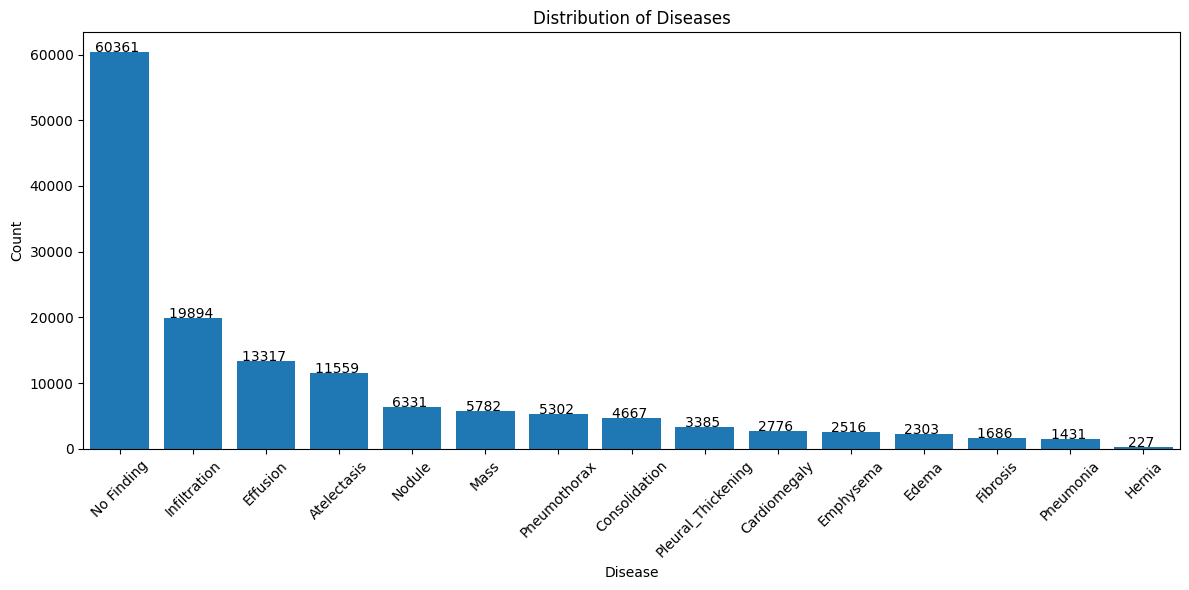

In [23]:
# Plot disease label distribution with value annotations on each bar
# This chart clearly shows the severe class imbalance:
# 'No Finding' (~60k) vs 'Hernia' (~227) — a ratio of approximately 265:1
# This imbalance must be addressed in preprocessing using weighted loss functions
_, ax = plt.subplots(figsize=(8, 5))
label_counts.plot(kind='bar', figsize=(12, 6))

bars = ax.bar(label_counts.index, label_counts.values)

# Annotate each bar with its exact count
for i in range(len(bars)):
    ax.text(
        i,
        label_counts.values[i] + 1,
        f"{label_counts.values[i]} ",
        ha='center'
    )

plt.title('Distribution of Diseases')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
def Show_Counts(cols, df=None, titles=None):
    """
    Plot bar charts for one or more categorical columns or Series.

    Automatically arranges subplots in a 3-column grid and annotates
    each bar with its exact count.

    Parameters
    ----------
    cols : list
        List of column name strings (requires df) or list of pandas Series.
    df : pd.DataFrame, optional
        Required when cols contains column name strings.
    titles : list of str, optional
        Custom subplot titles. Defaults to column names if not provided.

    Example
    -------
    Show_Counts(["Patient Gender"], df)
    Show_Counts([my_series_1, my_series_2], titles=["Title A", "Title B"])
    """
    n = len(cols)
    n_cols = 3
    n_rows = int(np.ceil(n / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]

        # Handle both column name strings and pre-computed Series
        try:
            col_counts = df[col].value_counts()
            colname = col
        except:
            col_counts = col.value_counts()
            colname = col_counts.index.name if col_counts.index.name else f"Column {i+1}"

        bars = ax.bar(col_counts.index.astype(str), col_counts.values)

        # Annotate each bar with its exact count
        for j, v in enumerate(col_counts.values):
            ax.text(j, v + 0.5, str(v), ha='center', fontsize=9)

        ax.set_title(titles[i] if titles else colname)
        ax.set_xlabel("")
        ax.set_ylabel("Count")

    # Hide any unused subplot slots in the grid
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()

## 9. Follow-up Breakdown by Age, Gender, and View Position

These helper functions generate grouped visualizations showing how demographics
and imaging conditions vary across the first three visit numbers (0, 1, 2).

In [25]:
def FilterByFollowUp_Age(n):
    """
    Generate age group distributions broken down by follow-up visit number.

    For each visit number from 0 to n-1, produces three subgroups:
    - MIX: all patients regardless of diagnosis
    - NO FINDING: healthy patients only
    - DISEASE FOUND: patients with at least one diagnosis

    Ages above 120 are excluded as outliers (data entry errors in the original dataset).

    Parameters
    ----------
    n : int
        Number of follow-up visits to include (starting from 0).

    Returns
    -------
    all_filters_data : list of pd.Series
        Age group Series for each subgroup and visit number.
    all_filters_titles : list of str
        Corresponding subplot titles for Show_Counts().
    """
    all_filters_data = []
    all_filters_titles = []

    for i in range(n):
        # Filter to current visit number, excluding age outliers
        base = df[df["Follow-up #"] == i][df["Patient Age"] < 120]

        mixed_group   = base["Patient Age"].apply(lambda x: set_age_group(x))
        healthy_group = base[base["Finding Labels"] == "No Finding"]["Patient Age"].apply(lambda x: set_age_group(x))
        disease_group = base[base["Finding Labels"] != "No Finding"]["Patient Age"].apply(lambda x: set_age_group(x))

        all_filters_data.extend([mixed_group, healthy_group, disease_group])
        all_filters_titles.extend([
            f"Age Group (MIX) at visit {i}",
            f"Age Group (NO FINDING) at visit {i}",
            f"Age Group (DISEASE FOUND) at visit {i}"
        ])

    return all_filters_data, all_filters_titles

In [26]:
def FilterByFollowUp_Gender(n):
    """
    Generate gender distributions broken down by follow-up visit number.

    Gender is encoded numerically for bar chart compatibility:
    M (Male) -> 0 | F (Female) -> 1

    Parameters
    ----------
    n : int
        Number of follow-up visits to include (starting from 0).

    Returns
    -------
    all_filters_data : list of pd.Series
    all_filters_titles : list of str
    """
    all_filters_data = []
    all_filters_titles = []

    for i in range(n):
        base = df[df["Follow-up #"] == i][df["Patient Age"] < 120]

        mixed_group   = base["Patient Gender"].replace({"M": 0, "F": 1})
        healthy_group = base[base["Finding Labels"] == "No Finding"]["Patient Gender"].replace({"M": 0, "F": 1})
        disease_group = base[base["Finding Labels"] != "No Finding"]["Patient Gender"].replace({"M": 0, "F": 1})

        all_filters_data.extend([mixed_group, healthy_group, disease_group])
        all_filters_titles.extend([
            f"Gender Group (MIX) at visit {i}",
            f"Gender Group (NO FINDING) at visit {i}",
            f"Gender Group (DISEASE FOUND) at visit {i}"
        ])

    return all_filters_data, all_filters_titles

In [27]:
def FilterByFollowUp_View(n):
    """
    Generate view position distributions broken down by follow-up visit number.

    View position is encoded numerically:
    PA (Posteroanterior) -> 0 | AP (Anteroposterior) -> 1

    PA is the standard standing view with higher diagnostic image quality.
    AP is typically used for bedridden or critically ill patients.

    Parameters
    ----------
    n : int
        Number of follow-up visits to include (starting from 0).

    Returns
    -------
    all_filters_data : list of pd.Series
    all_filters_titles : list of str
    """
    all_filters_data = []
    all_filters_titles = []

    for i in range(n):
        base = df[df["Follow-up #"] == i]

        mixed_group   = base["View Position"].replace({"PA": 0, "AP": 1})
        healthy_group = base[base["Finding Labels"] == "No Finding"]["View Position"].replace({"PA": 0, "AP": 1})
        disease_group = base[base["Finding Labels"] != "No Finding"]["View Position"].replace({"PA": 0, "AP": 1})

        all_filters_data.extend([mixed_group, healthy_group, disease_group])
        all_filters_titles.extend([
            "View Position (MIX)",
            "View Position (NO FINDING Captured)",
            "View Position (DISEASE Captured)"
        ])

    return all_filters_data, all_filters_titles

## 10. Demographic Charts

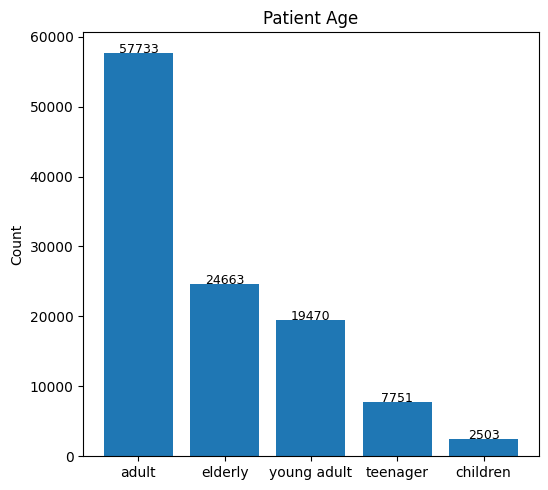

In [28]:
# Overall age group distribution across the entire dataset
Show_Counts([df["Patient Age"].apply(lambda x: set_age_group(x))], df)

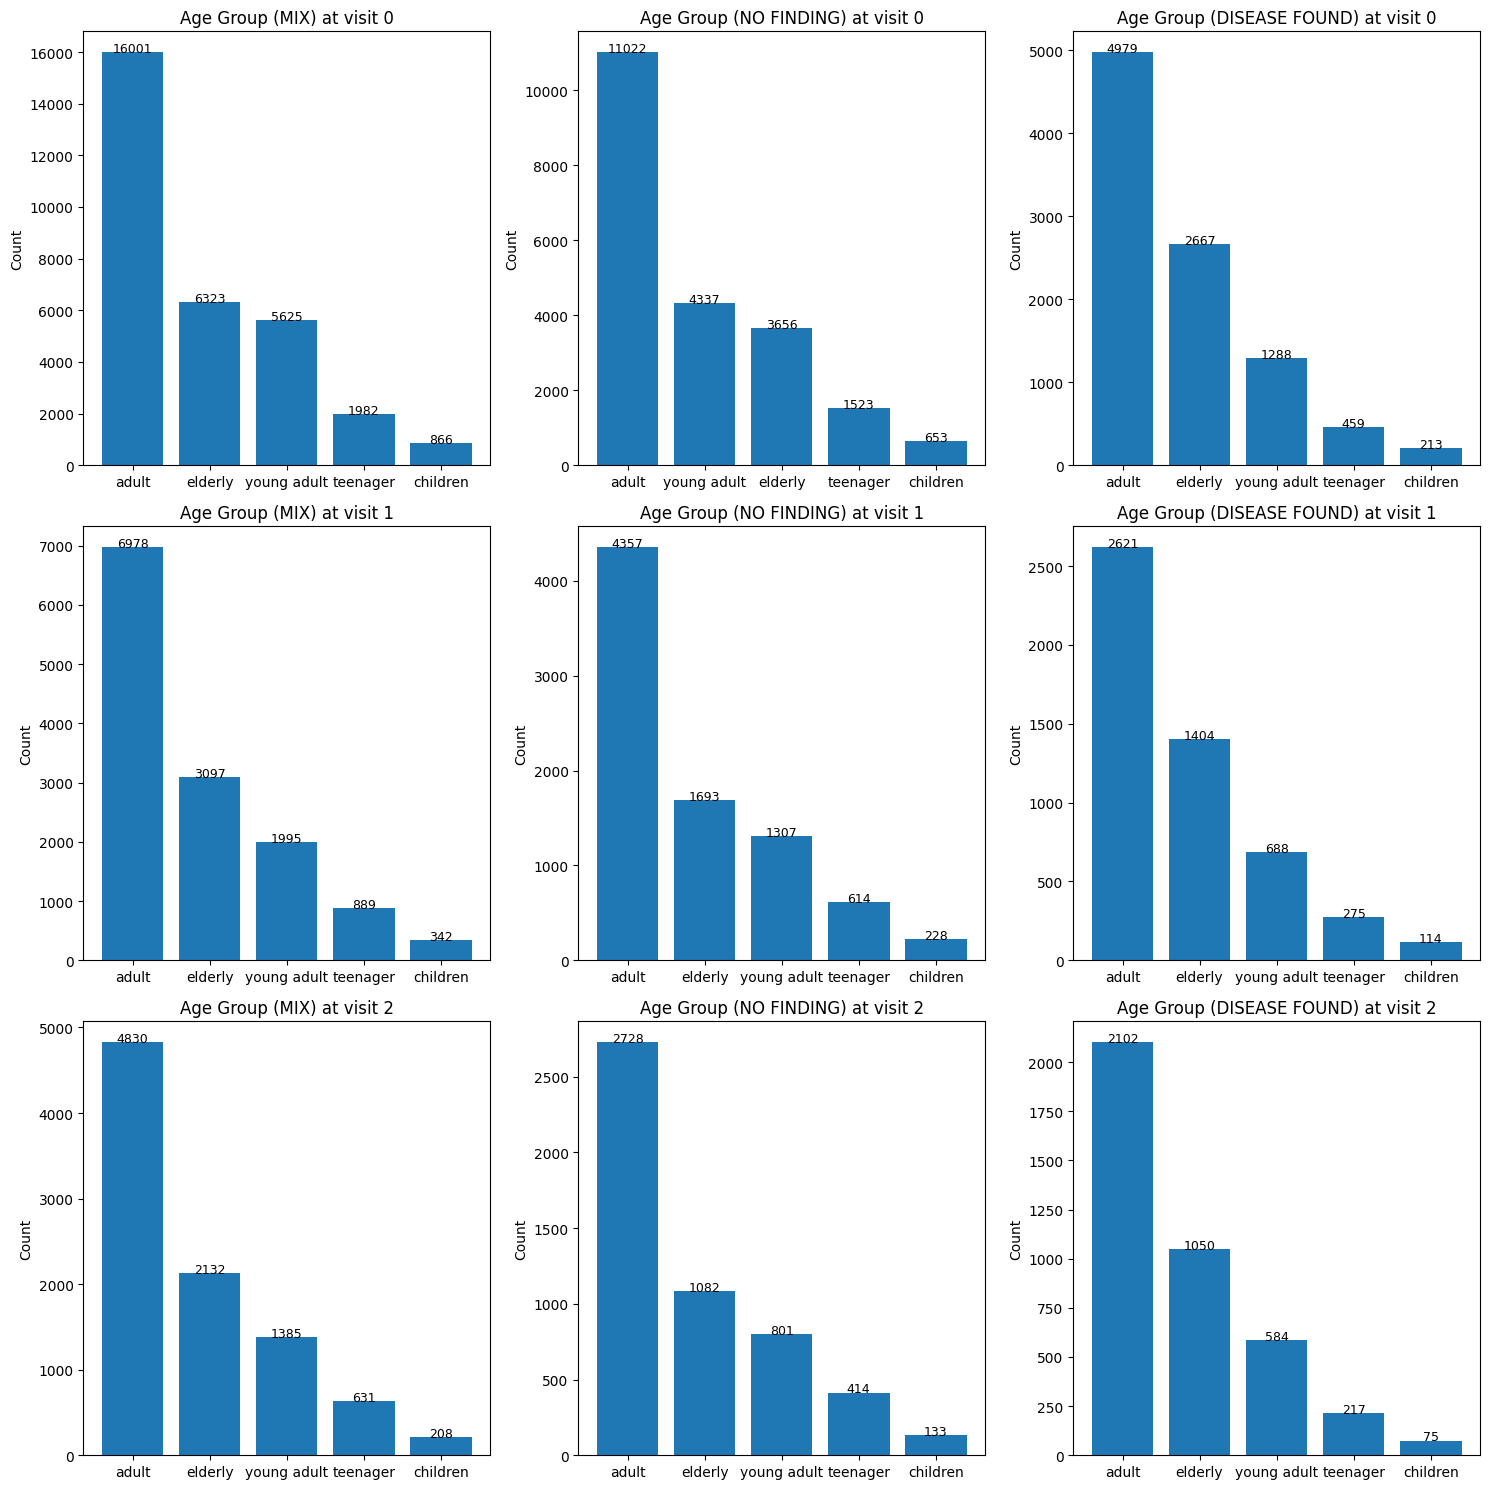

In [29]:
# Age group breakdown across first 3 visit numbers (0, 1, 2)
# Shows how age distribution shifts between healthy and diseased patients across visits
all_data, all_titles = FilterByFollowUp_Age(3)
Show_Counts(all_data, df, all_titles)

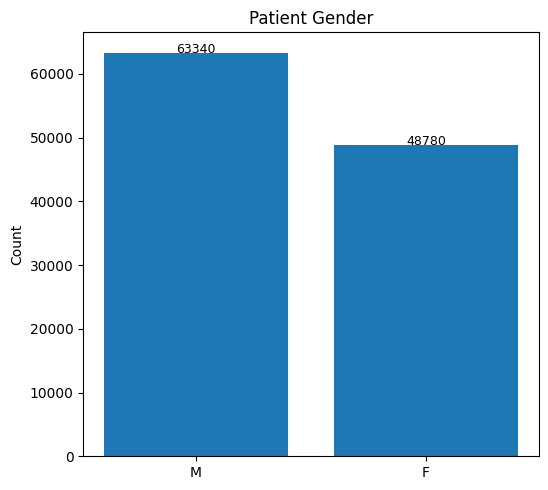

In [30]:
# Overall gender distribution (Male vs Female) across the entire dataset
Show_Counts(["Patient Gender"], df)

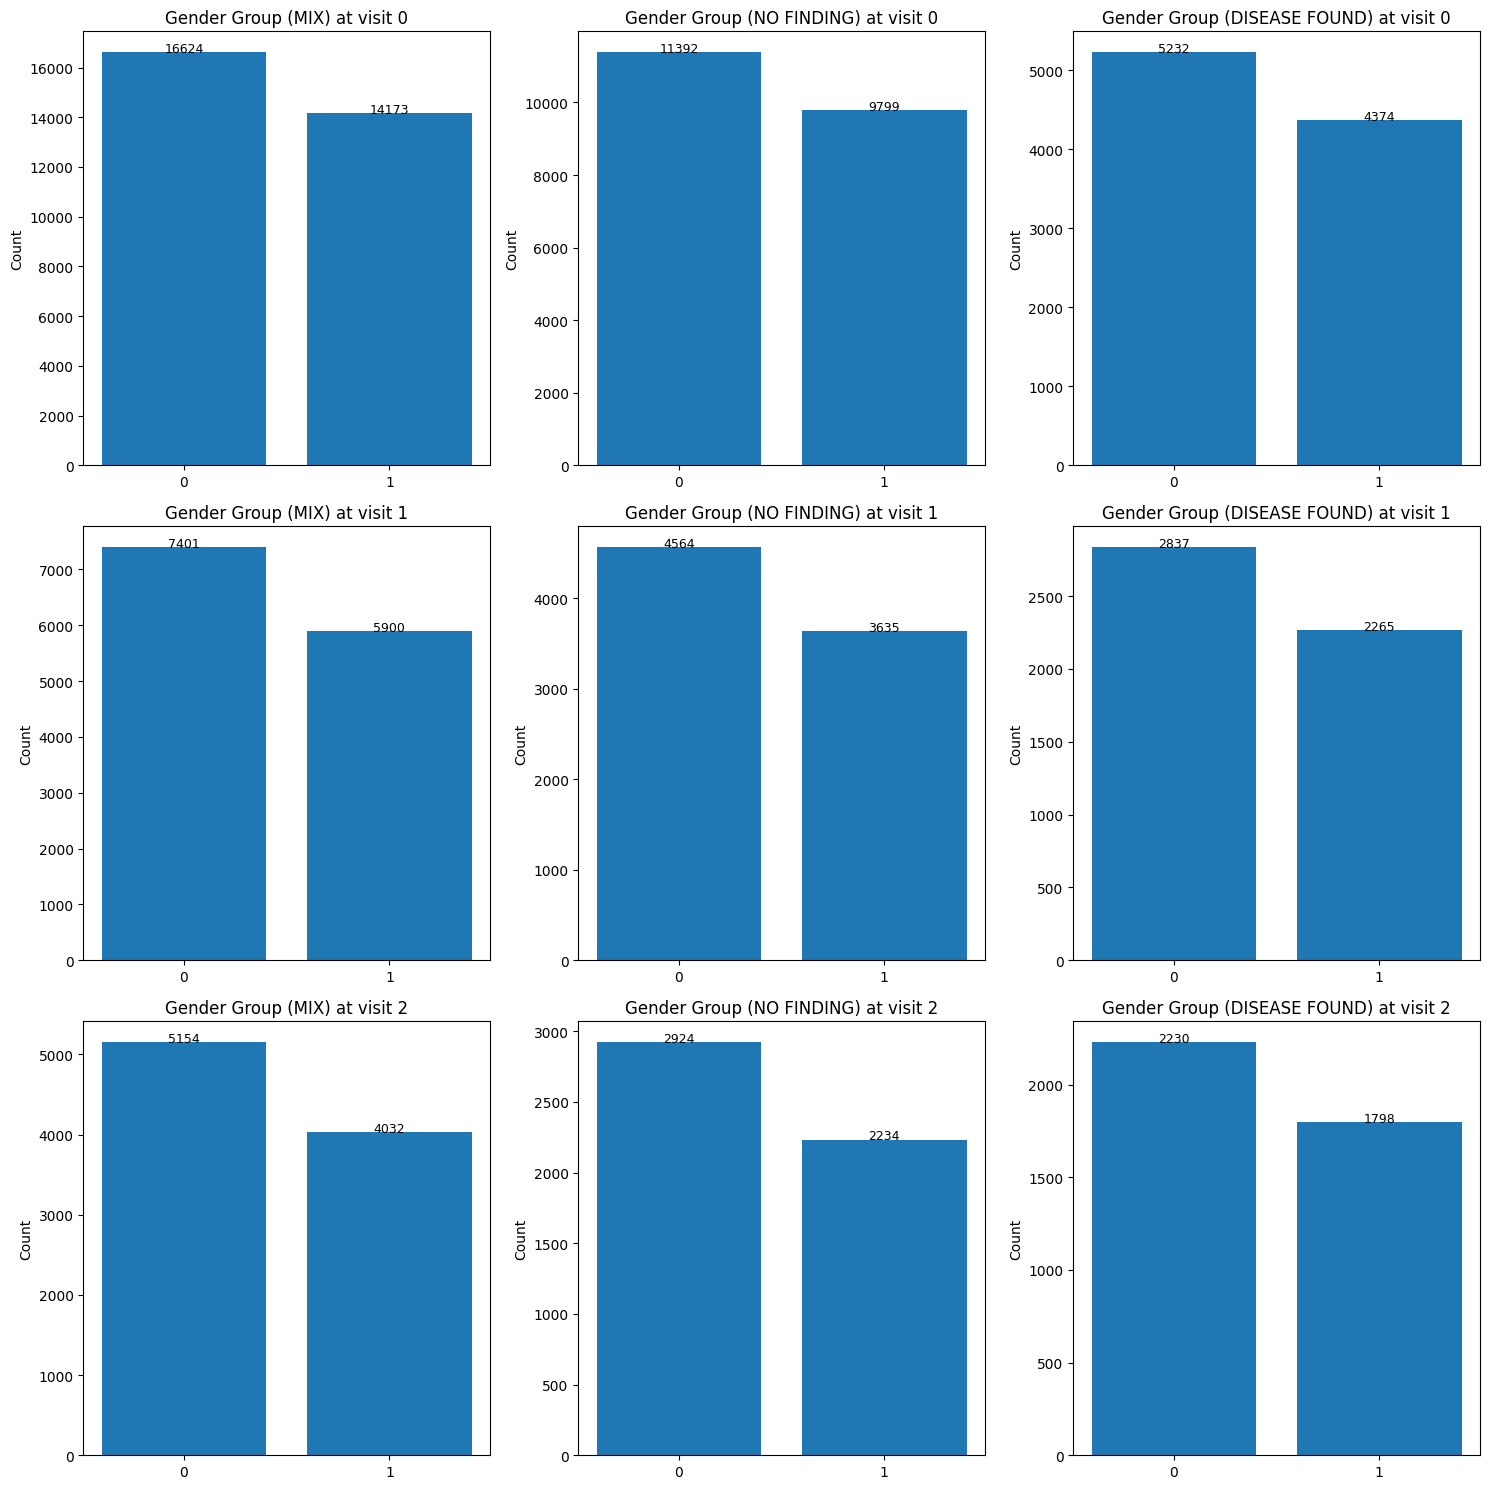

In [31]:
# Gender breakdown across first 3 visit numbers
# Helps identify whether gender influences follow-up patterns or disease prevalence
all_data, all_titles = FilterByFollowUp_Gender(3)
Show_Counts(all_data, df, all_titles)

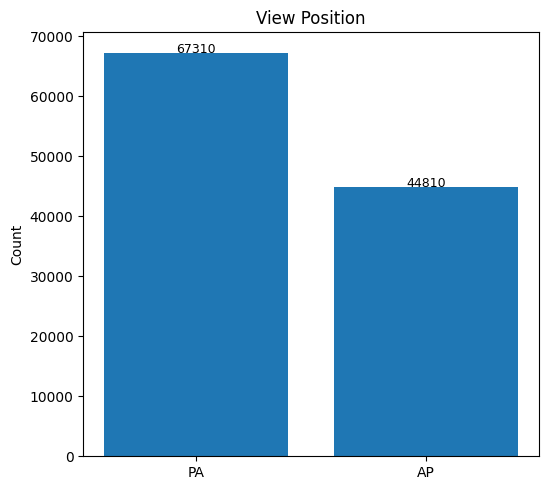

In [32]:
# Overall distribution of imaging view positions (PA vs AP)
Show_Counts(["View Position"], df)

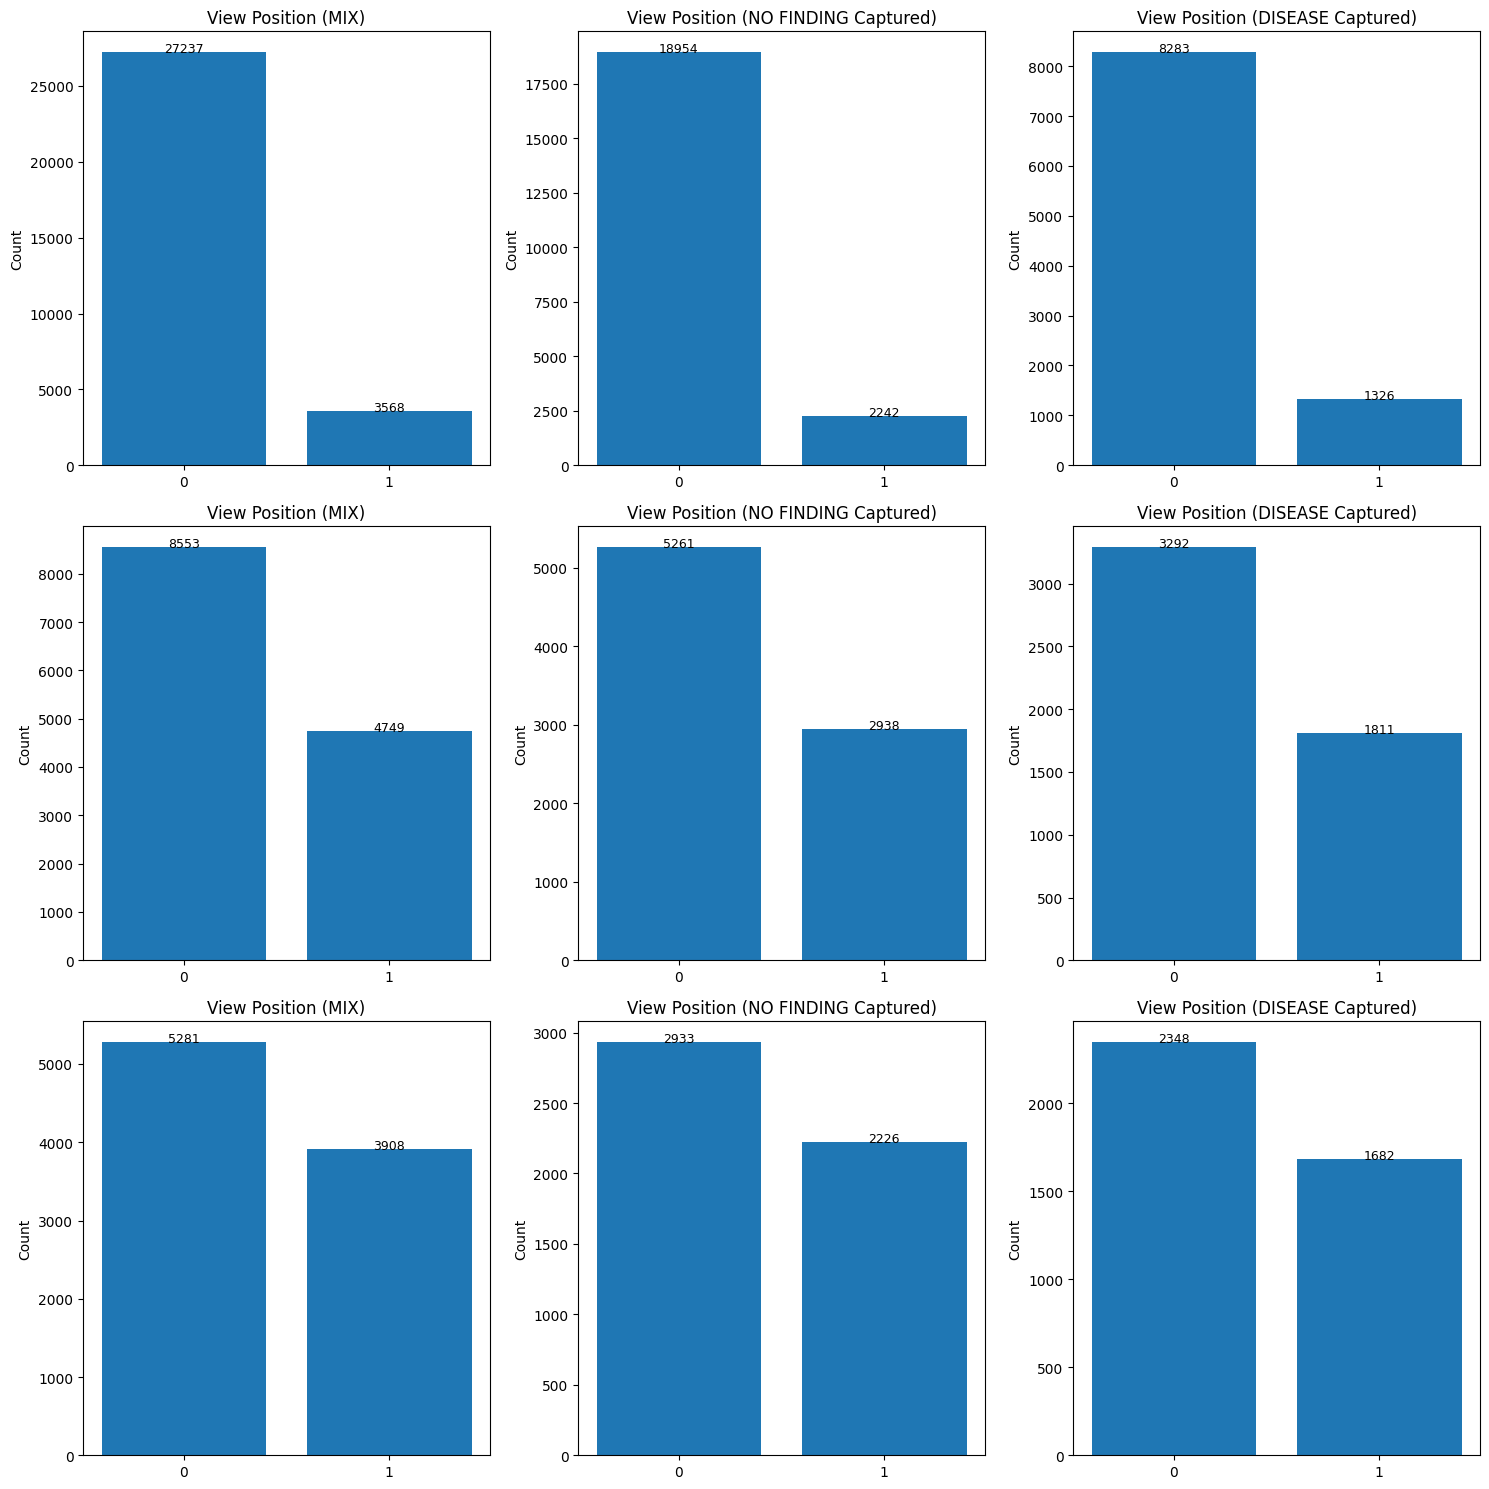

In [33]:
# View position breakdown across first 3 visit numbers
# Helps understand whether AP or PA is more common in diseased vs healthy patients
all_data, all_titles = FilterByFollowUp_View(3)
Show_Counts(all_data, df, all_titles)

## 11. Image Path Setup

The dataset images are distributed across 12 ZIP folders (`images_001` to `images_012`).  
We collect all folder paths here to support image loading in the visualization section.

In [34]:
# Root directory where all image folders are stored
# Update this path to match your local dataset location
DATA_PATH = r"D:\Data"

# Collect paths for all extracted image subfolders (images_001 to images_012)
# Each folder contains a nested 'images' directory with the PNG files
ALL_FOLDERS_PATH = [
    os.path.join(DATA_PATH, x + "\\images")
    for x in os.listdir(DATA_PATH)
    if x.startswith("images_")
]

ALL_FOLDERS_PATH

['D:\\Data\\images_001\\images',
 'D:\\Data\\images_002\\images',
 'D:\\Data\\images_003\\images',
 'D:\\Data\\images_004\\images',
 'D:\\Data\\images_005\\images',
 'D:\\Data\\images_006\\images',
 'D:\\Data\\images_007\\images',
 'D:\\Data\\images_008\\images',
 'D:\\Data\\images_009\\images',
 'D:\\Data\\images_010\\images',
 'D:\\Data\\images_011\\images',
 'D:\\Data\\images_012\\images']

Image shape: (1024, 1024)


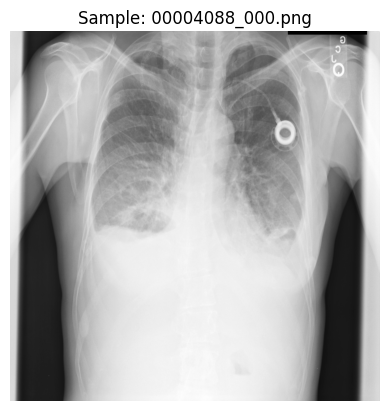

In [35]:
# Quick sanity check: load and display a single random X-ray image
# Verifies that image paths are correctly configured and files are readable
# Expected image shape: (1024, 1024) — grayscale PNG
img_item = np.random.choice(df["Image Index"].values)

for f in ALL_FOLDERS_PATH:
    if img_item in os.listdir(f):
        img = plt.imread(os.path.join(f, img_item))
        print(f"Image shape: {img.shape}")
        plt.imshow(img, cmap='gray')
        plt.axis("off")
        plt.title(f"Sample: {img_item}")
        plt.show()
        break

## 12. Visual Sample Inspection

Display random X-ray samples with their associated metadata (label, view position, age, gender).  
Samples are shown separately for PA and AP views to highlight visual quality differences.

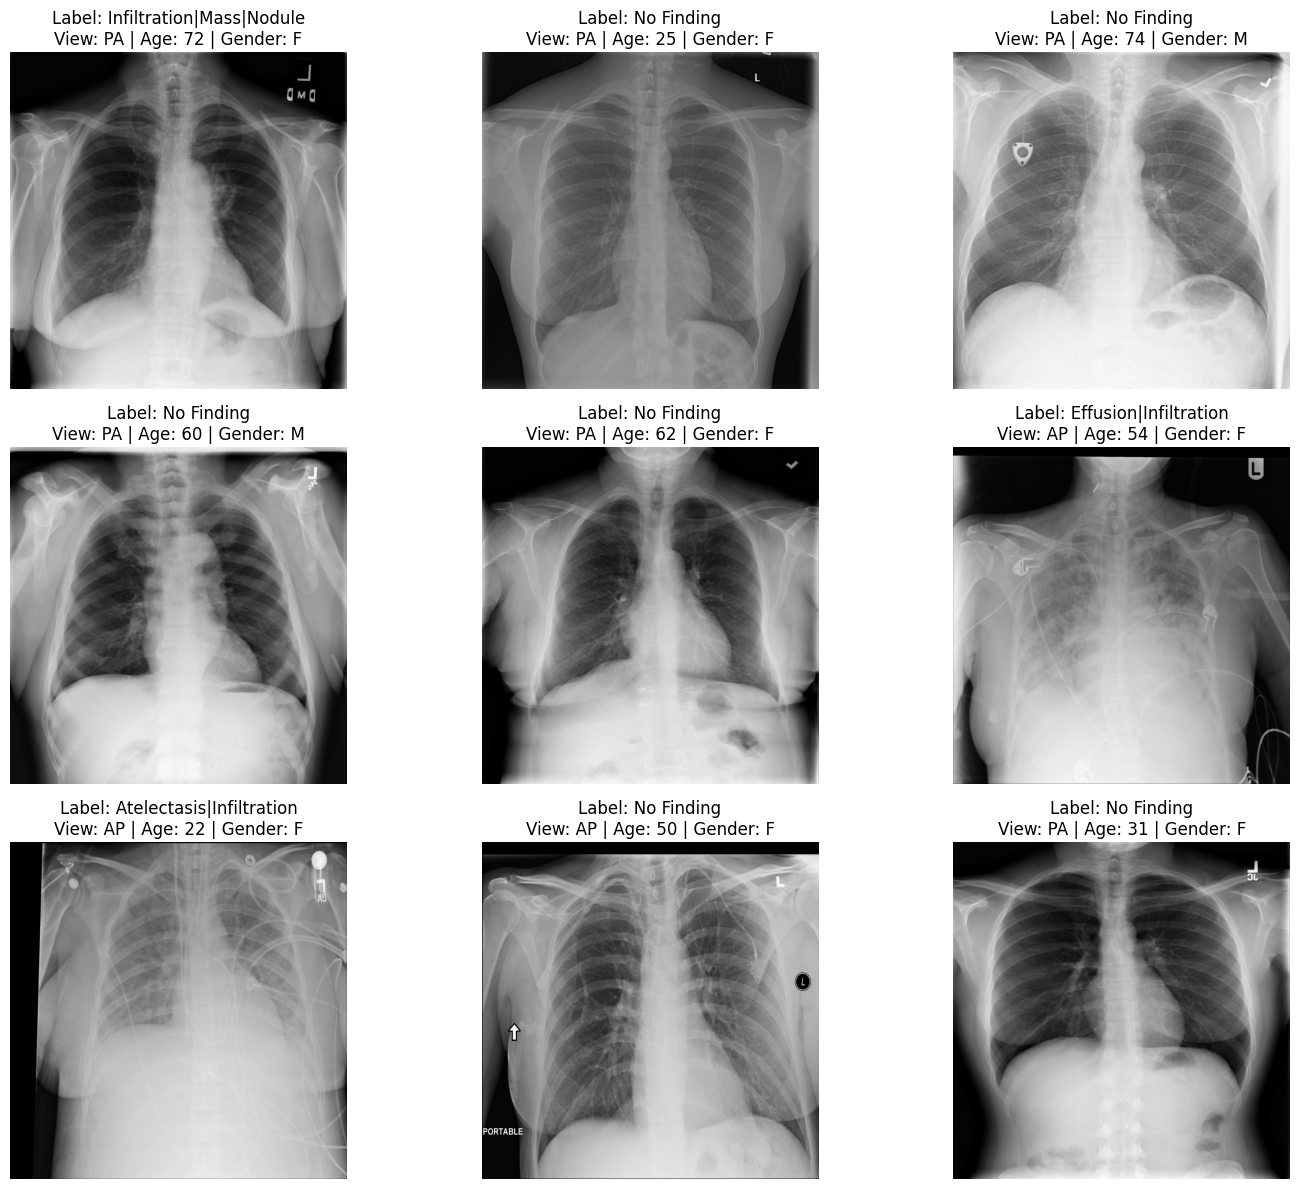

In [36]:
def Show_Sample(df):
    """
    Display a 3x3 grid of randomly selected chest X-ray images with metadata.

    Each image is shown in grayscale with its associated:
    - Finding Labels (disease diagnosis or 'No Finding')
    - View Position (PA or AP)
    - Patient Age
    - Patient Gender

    The function searches across all image folders to locate each file.

    Parameters
    ----------
    df : pd.DataFrame
        Subset of the metadata dataframe to sample images from.
        Can be filtered by any condition (e.g., view position, disease label).
    """
    _, ax = plt.subplots(3, 3, figsize=(15, 12))
    ax = ax.flatten()

    for i in range(9):
        # Randomly select an image filename from the filtered subset
        img_item = np.random.choice(df["Image Index"].values)

        # Search across all image folders to locate this specific file
        for f in ALL_FOLDERS_PATH:
            if img_item in os.listdir(f):
                # Retrieve corresponding metadata for the selected image
                label    = df[df["Image Index"] == img_item]["Finding Labels"].values[0]
                age      = df[df["Image Index"] == img_item]["Patient Age"].values[0]
                gender   = df[df["Image Index"] == img_item]["Patient Gender"].values[0]
                view_pos = df[df["Image Index"] == img_item]["View Position"].values[0]

                # Render image with metadata as subplot title
                ax[i].imshow(plt.imread(os.path.join(f, img_item)), cmap='gray')
                ax[i].set_title(
                    f"Label: {label}\n"
                    f"View: {view_pos} | Age: {age} | Gender: {gender}"
                )
                ax[i].axis("off")
                break

    plt.tight_layout()
    plt.show()


# Display 9 random samples from the full dataset
Show_Sample(df)

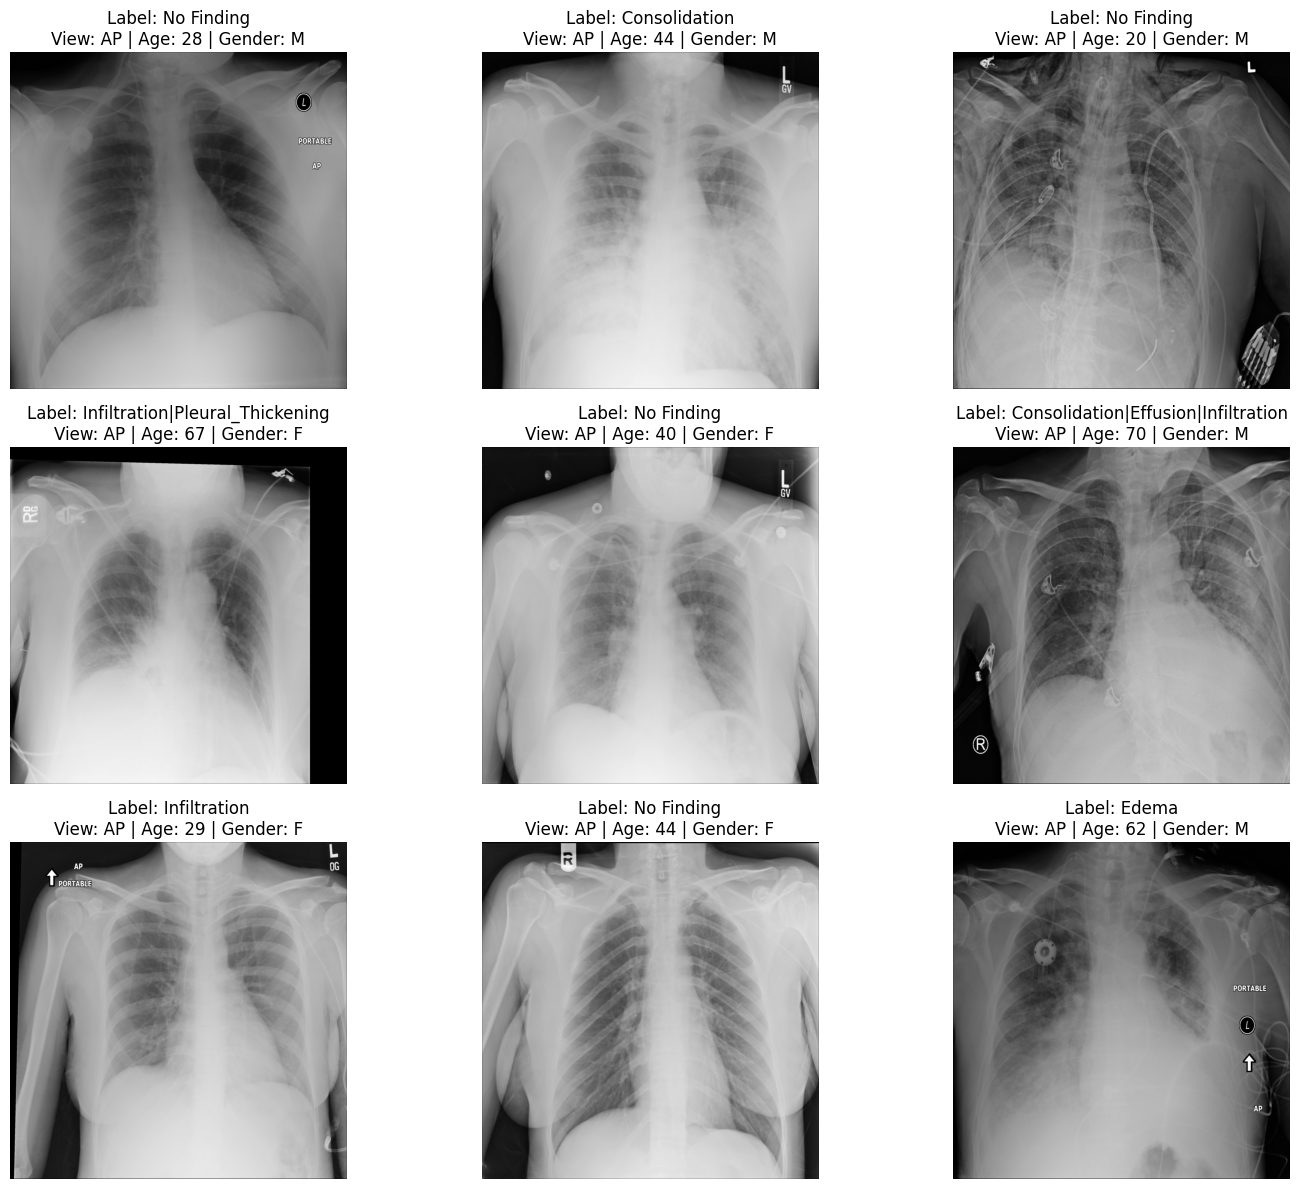

In [37]:
# Display 9 random AP (Anteroposterior) view samples
# AP images are typically lower contrast and taken for bedridden patients
Show_Sample(df[df["View Position"] == "AP"])

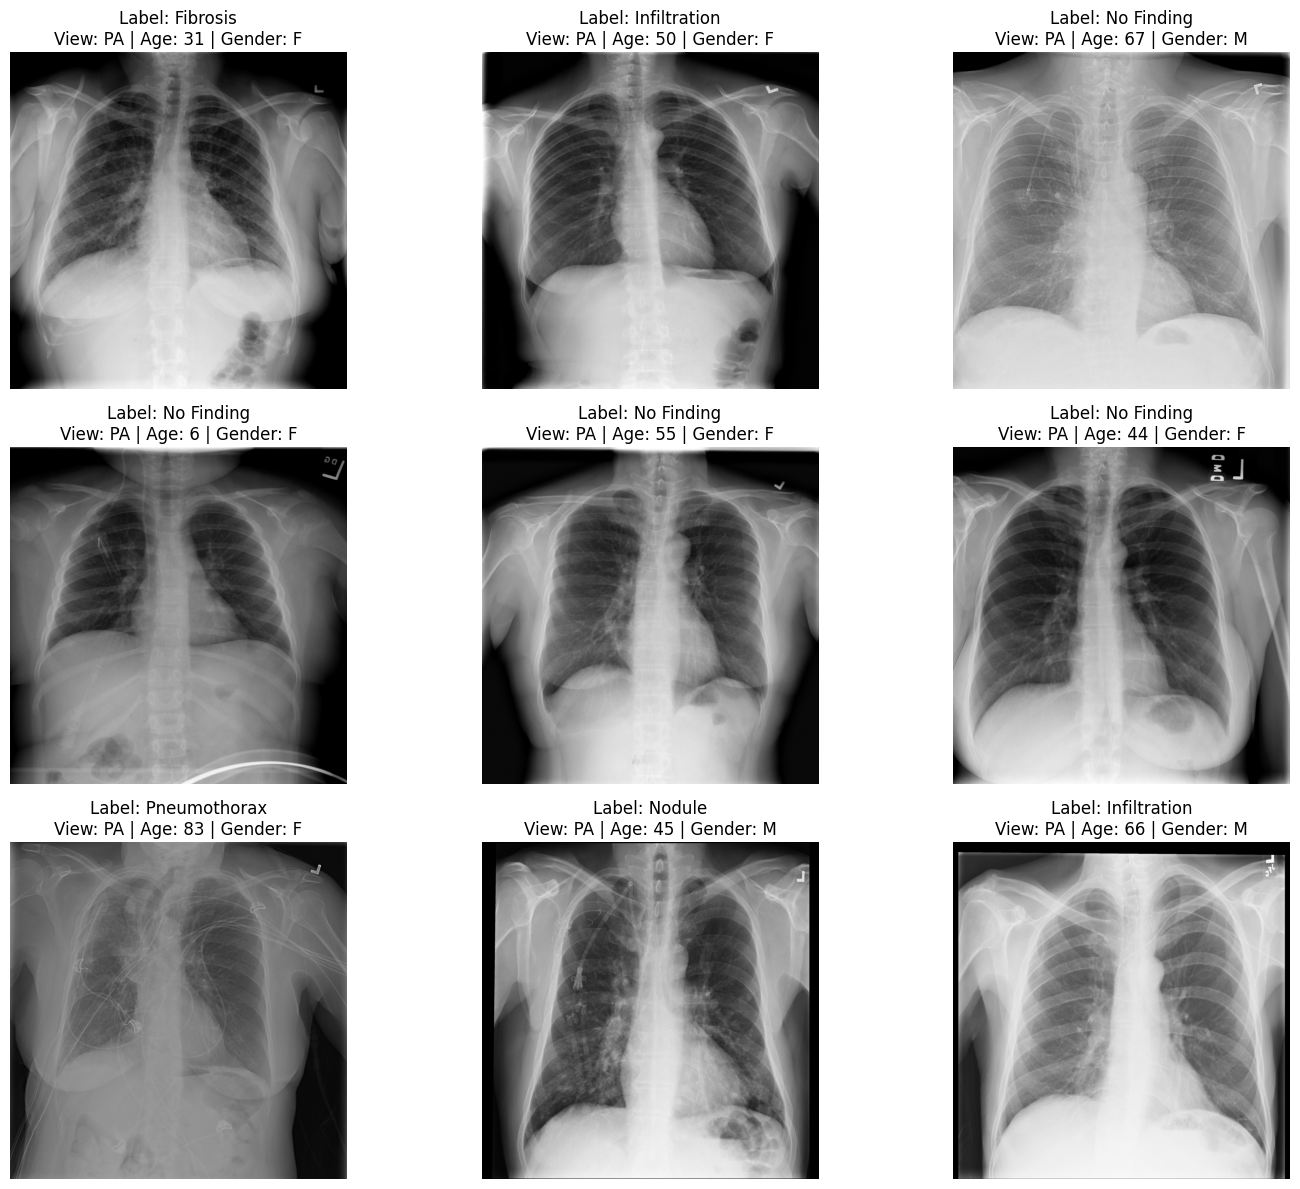

In [38]:
# Display 9 random PA (Posteroanterior) view samples
# PA images are the standard clinical view with higher diagnostic image quality
Show_Sample(df[df["View Position"] == "PA"])

## 13. EDA Summary & Key Findings

| Metric | Value |
|--------|-------|
| Total images | 112,120 |
| Unique patients | 30,805 |
| Disease classes | 14 + No Finding |
| Multi-label images | Yes (pipe-separated labels) |
| Missing values | Only in trailing empty column (Unnamed: 11) |
| Image resolution | 1024 x 1024 px |
| View positions | PA: 67,310 | AP: 44,810 |
| Gender split | Male: 63,340 | Female: 48,780 |
| Age range (valid) | 1 to 120 years |
| Most common class | No Finding (~60,361 images) |
| Rarest class | Hernia (~227 images) |

---